In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

transactions = pd.read_csv(
    "../data/transactions.csv"
)

customers = pd.read_csv(
    "../data/customers.csv"
)

accounts = pd.read_csv(
    "../data/accounts.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print("Data loaded successfully!")

Data loaded successfully!


In [2]:
print("Customers:", customers.shape)
print("Accounts:", accounts.shape)
print("Transactions:", transactions.shape)

Customers: (1000, 4)
Accounts: (1000, 3)
Transactions: (20000, 9)


In [3]:
transactions.head()

,transaction_id,account_id,transaction_date,transaction_type,amount,merchant,location,channel,is_fraud
0,1,ACC00845,2025-04-08 22:21:00,Purchase,297.89,Local Store,Kolkata,Branch,0
1,2,ACC00603,2025-03-05 14:29:00,Deposit,157.86,Myntra,Delhi,POS,1
2,3,ACC00754,2025-01-25 17:59:00,Payment,346.43,Reliance,Ahmedabad,POS,0
3,4,ACC00933,2025-04-01 22:37:00,Withdrawal,831.33,BookMyShow,Mumbai,Online,0
4,5,ACC00621,2025-06-14 16:56:00,Payment,143.43,Zomato,Bangalore,Branch,0


In [4]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    20000 non-null  int64         
 1   account_id        20000 non-null  str           
 2   transaction_date  20000 non-null  datetime64[us]
 3   transaction_type  20000 non-null  str           
 4   amount            20000 non-null  float64       
 5   merchant          20000 non-null  str           
 6   location          20000 non-null  str           
 7   channel           20000 non-null  str           
 8   is_fraud          20000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 2.1 MB


In [5]:
transactions.describe()

,transaction_id,transaction_date,amount,is_fraud
count,20000.000000,20000,20000.000000,20000.000000
mean,10000.500000,2025-07-02 18:16:20.493000,301.716415,0.024200
min,1.000000,2025-01-01 00:10:00,3.590000,0.000000
25%,5000.750000,2025-04-02 23:19:00,93.107500,0.000000
50%,10000.500000,2025-07-03 09:49:30,182.675000,0.000000
75%,15000.250000,2025-10-01 09:32:45,358.495000,0.000000
max,20000.000000,2025-12-31 23:51:00,15979.860000,1.000000
std,5773.647028,NaN,408.446920,0.153673


In [6]:
transactions.isnull().sum()

transaction_id      0
account_id          0
transaction_date    0
transaction_type    0
amount              0
merchant            0
location            0
channel             0
is_fraud            0
dtype: int64

In [7]:
transactions["is_fraud"].value_counts()

is_fraud
0    19516
1      484
Name: count, dtype: int64

In [8]:
fraud_percentage = (
    transactions["is_fraud"]
    .mean() * 100
)

print(
    f"Fraud percentage: "
    f"{fraud_percentage:.2f}%"
)

Fraud percentage: 2.42%


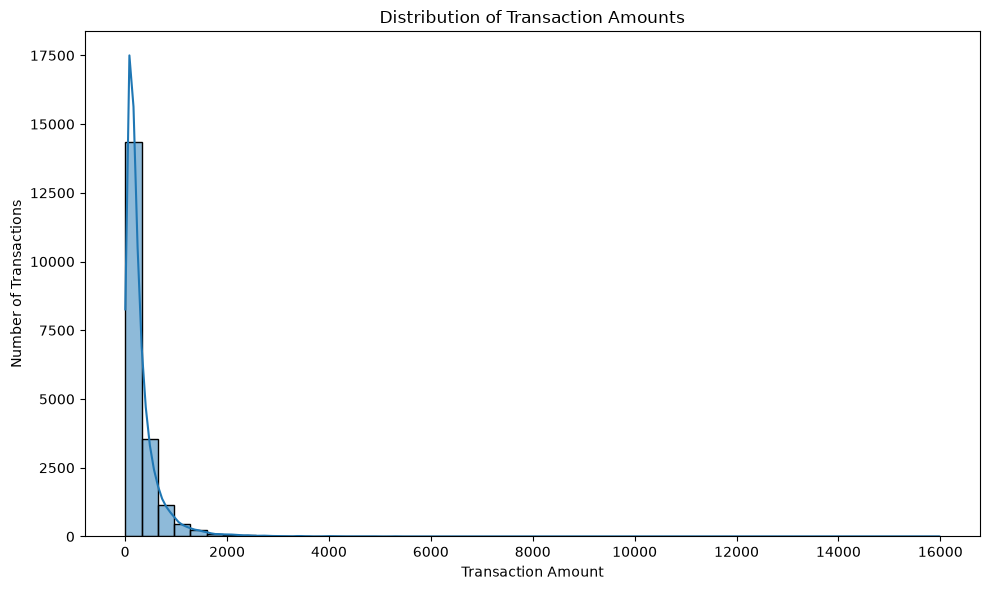

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=transactions,
    x="amount",
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

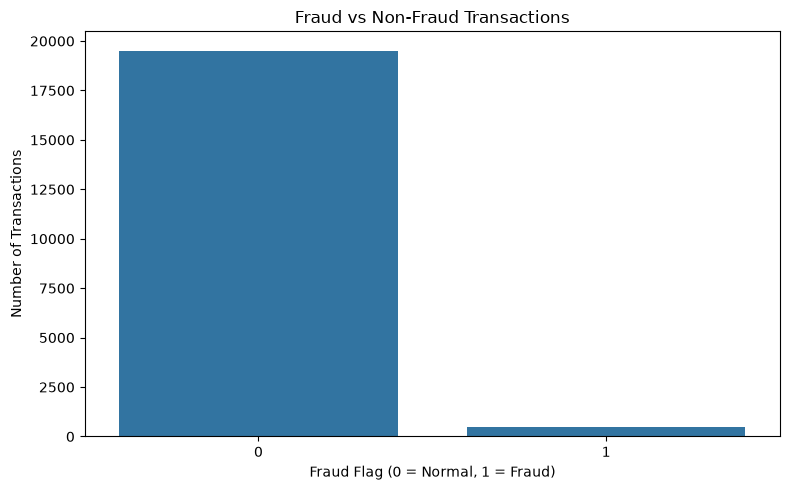

In [10]:
fraud_counts = transactions["is_fraud"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=fraud_counts.index,
    y=fraud_counts.values
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Flag (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [11]:
fraud_counts

is_fraud
0    19516
1      484
Name: count, dtype: int64

In [12]:
fraud_counts_normalized = (
    transactions["is_fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

fraud_counts_normalized

is_fraud
0    97.58
1     2.42
Name: proportion, dtype: float64

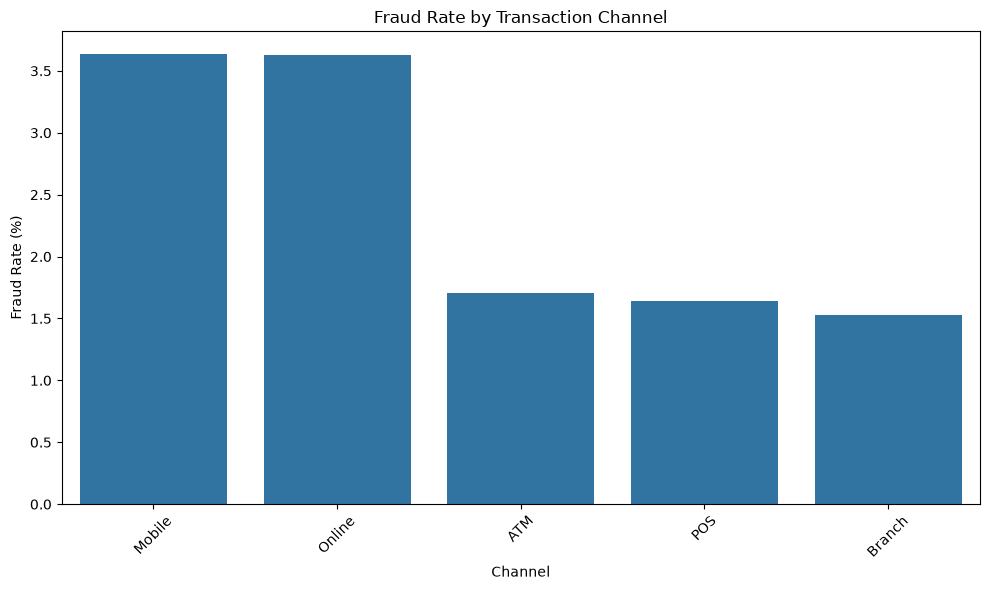

In [13]:
channel_fraud = (
    transactions
    .groupby("channel")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=channel_fraud.index,
    y=channel_fraud.values
)

plt.title("Fraud Rate by Transaction Channel")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
channel_fraud.round(2)

channel
Mobile    3.64
Online    3.62
ATM       1.71
POS       1.64
Branch    1.53
Name: is_fraud, dtype: float64

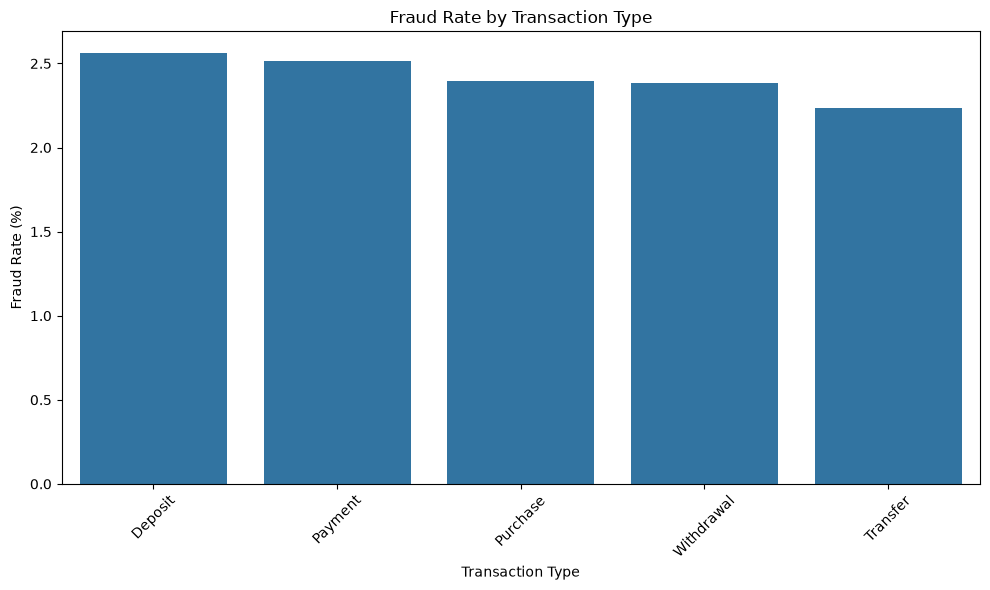

In [15]:
type_fraud = (
    transactions
    .groupby("transaction_type")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=type_fraud.index,
    y=type_fraud.values
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
type_fraud.round(2)

transaction_type
Deposit       2.56
Payment       2.52
Purchase      2.40
Withdrawal    2.38
Transfer      2.23
Name: is_fraud, dtype: float64

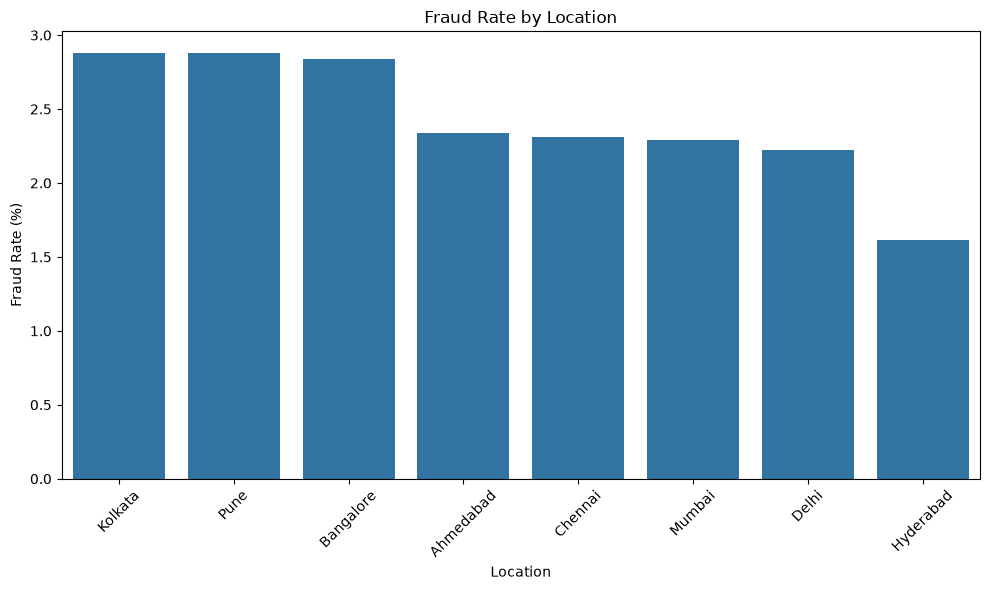

In [17]:
location_fraud = (
    transactions
    .groupby("location")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=location_fraud.index,
    y=location_fraud.values
)

plt.title("Fraud Rate by Location")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
location_fraud.round(2)

location
Kolkata      2.88
Pune         2.88
Bangalore    2.84
Ahmedabad    2.34
Chennai      2.31
Mumbai       2.29
Delhi        2.22
Hyderabad    1.61
Name: is_fraud, dtype: float64

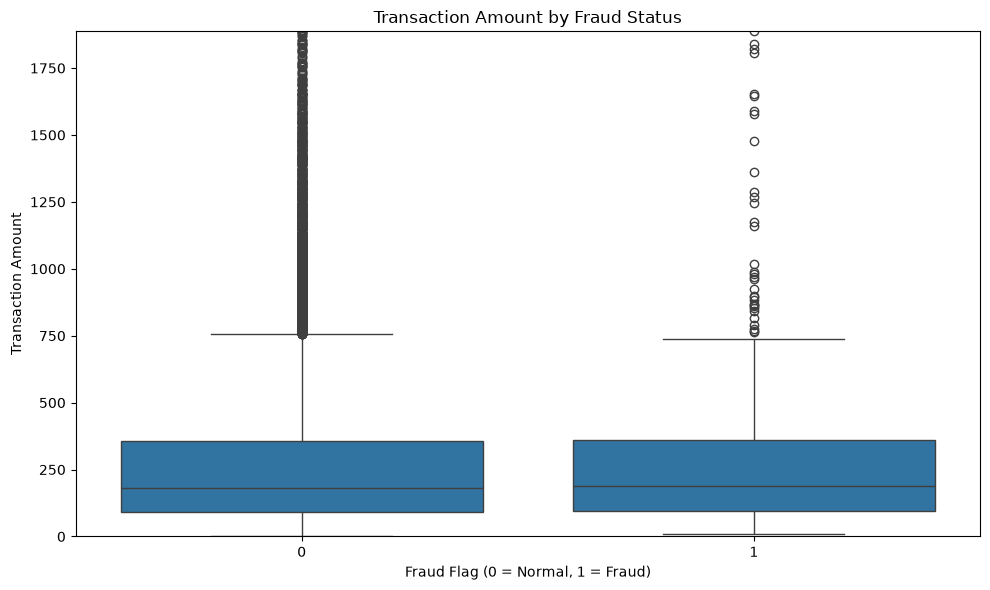

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=transactions,
    x="is_fraud",
    y="amount"
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Flag (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.ylim(
    0,
    transactions["amount"].quantile(0.99)
)

plt.tight_layout()
plt.show()

In [21]:
amount_by_fraud = (
    transactions
    .groupby("is_fraud")["amount"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
)

amount_by_fraud

,count,mean,median,min,max
is_fraud,,,,,
0,19516,301.103969,182.565,3.59,15979.86
1,484,326.411653,187.210,9.68,9342.52


In [22]:
transactions["hour"] = (
    transactions["transaction_date"]
    .dt.hour
)

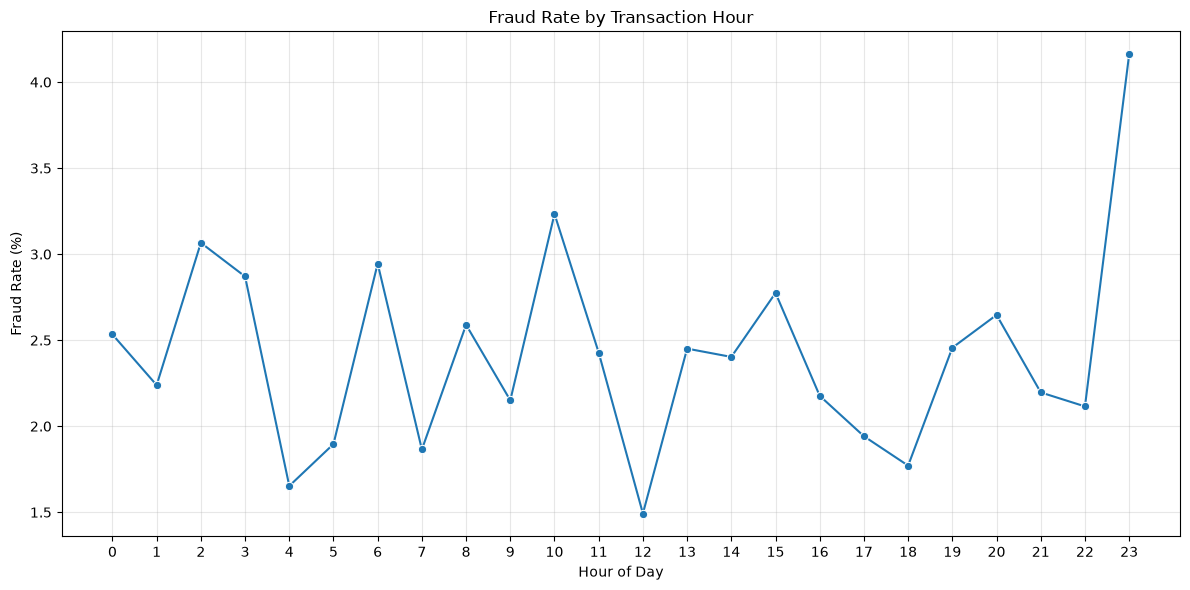

In [23]:
hourly_fraud = (
    transactions
    .groupby("hour")["is_fraud"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_fraud.index,
    y=hourly_fraud.values,
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
hourly_fraud.round(2)

hour
0     2.53
1     2.24
2     3.07
3     2.87
4     1.65
5     1.90
6     2.94
7     1.86
8     2.59
9     2.15
10    3.23
11    2.43
12    1.49
13    2.45
14    2.40
15    2.77
16    2.18
17    1.94
18    1.77
19    2.46
20    2.65
21    2.20
22    2.12
23    4.16
Name: is_fraud, dtype: float64

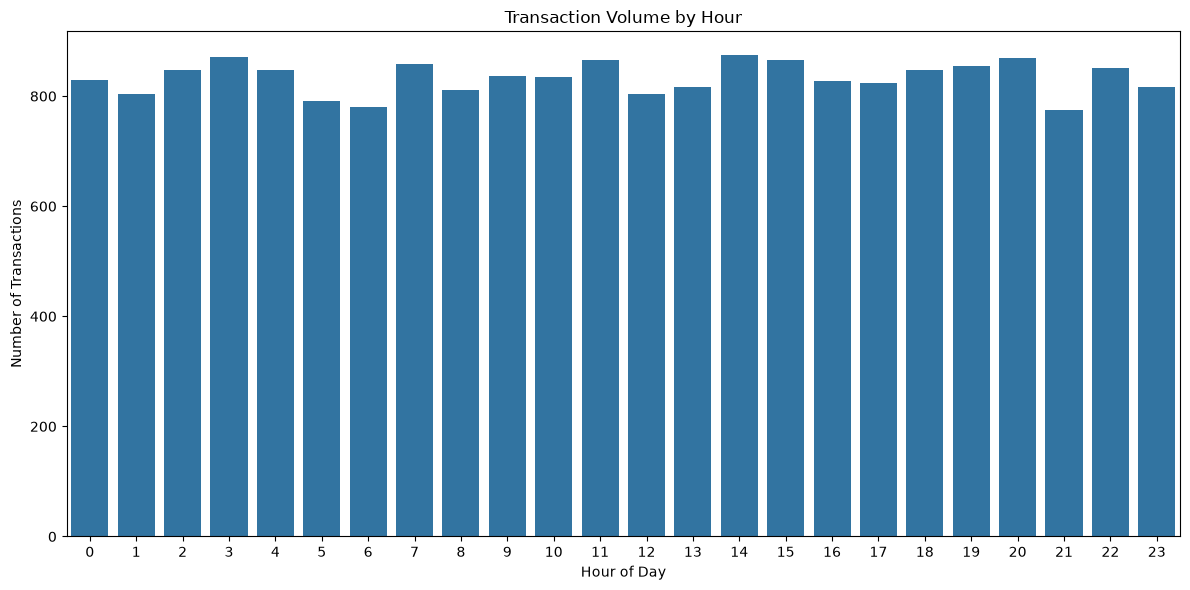

In [25]:
hourly_volume = (
    transactions
    .groupby("hour")
    .size()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=hourly_volume.index,
    y=hourly_volume.values
)

plt.title("Transaction Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [26]:
# Make a working copy
df = transactions.copy()

# Time-based features
df["hour"] = df["transaction_date"].dt.hour
df["day_of_week"] = df["transaction_date"].dt.dayofweek
df["day_of_month"] = df["transaction_date"].dt.day
df["month"] = df["transaction_date"].dt.month

# Weekend indicator
df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

# High-value transaction indicator
df["is_high_value"] = (
    df["amount"] >= 10000
).astype(int)

df.head()

,transaction_id,account_id,transaction_date,transaction_type,amount,merchant,location,channel,is_fraud,hour,day_of_week,day_of_month,month,is_weekend,is_high_value
0,1,ACC00845,2025-04-08 22:21:00,Purchase,297.89,Local Store,Kolkata,Branch,0,22,1,8,4,0,0
1,2,ACC00603,2025-03-05 14:29:00,Deposit,157.86,Myntra,Delhi,POS,1,14,2,5,3,0,0
2,3,ACC00754,2025-01-25 17:59:00,Payment,346.43,Reliance,Ahmedabad,POS,0,17,5,25,1,1,0
3,4,ACC00933,2025-04-01 22:37:00,Withdrawal,831.33,BookMyShow,Mumbai,Online,0,22,1,1,4,0,0
4,5,ACC00621,2025-06-14 16:56:00,Payment,143.43,Zomato,Bangalore,Branch,0,16,5,14,6,1,0


In [27]:
df[
    [
        "transaction_date",
        "amount",
        "hour",
        "day_of_week",
        "month",
        "is_weekend",
        "is_high_value",
        "is_fraud"
    ]
].head(10)

,transaction_date,amount,hour,day_of_week,month,is_weekend,is_high_value,is_fraud
0,2025-04-08 22:21:00,297.89,22,1,4,0,0,0
1,2025-03-05 14:29:00,157.86,14,2,3,0,0,1
2,2025-01-25 17:59:00,346.43,17,5,1,1,0,0
3,2025-04-01 22:37:00,831.33,22,1,4,0,0,0
4,2025-06-14 16:56:00,143.43,16,5,6,1,0,0
5,2025-05-31 14:51:00,143.43,14,5,5,1,0,0
6,2025-09-20 09:53:00,879.38,9,5,9,1,0,0
7,2025-05-29 21:22:00,390.50,21,3,5,0,0,0
8,2025-10-15 15:37:00,113.36,15,2,10,0,0,0
9,2025-02-24 00:24:00,311.86,0,0,2,0,0,0


In [28]:
numeric_features = [
    "amount",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "is_high_value",
    "is_fraud"
]

correlation_matrix = df[
    numeric_features
].corr()

correlation_matrix

,amount,hour,day_of_week,day_of_month,month,is_weekend,is_high_value,is_fraud
amount,1.000000,-0.003299,-0.012666,0.008511,-0.003105,-0.015267,0.271435,0.009522
hour,-0.003299,1.000000,-0.006979,0.017728,-0.004602,0.000272,-0.003601,0.003005
day_of_week,-0.012666,-0.006979,1.000000,0.002426,-0.015319,0.786951,-0.003485,-0.012260
day_of_month,0.008511,0.017728,0.002426,1.000000,0.008056,-0.010450,0.005103,-0.005013
month,-0.003105,-0.004602,-0.015319,0.008056,1.000000,-0.005185,-0.011382,0.000376
is_weekend,-0.015267,0.000272,0.786951,-0.010450,-0.005185,1.000000,-0.004382,-0.011852
is_high_value,0.271435,-0.003601,-0.003485,0.005103,-0.011382,-0.004382,1.000000,-0.001114
is_fraud,0.009522,0.003005,-0.012260,-0.005013,0.000376,-0.011852,-0.001114,1.000000


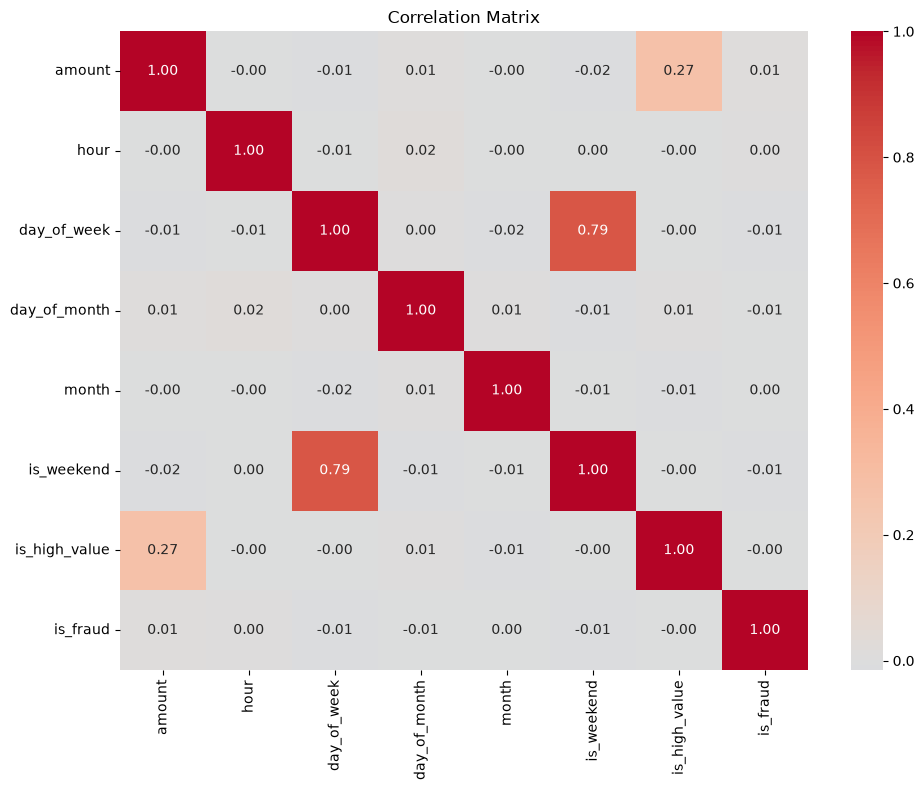

In [29]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [30]:
# Select features for machine learning

features = [
    "amount",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "is_high_value",
    "transaction_type",
    "channel",
    "location",
    "merchant"
]

target = "is_fraud"

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20000, 11)
Target shape: (20000,)


In [32]:
X.select_dtypes(
    include=["str", "object"]
).columns.tolist()

['transaction_type', 'channel', 'location', 'merchant']

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [34]:
numeric_features = [
    "amount",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "is_high_value"
]

categorical_features = [
    "transaction_type",
    "channel",
    "location",
    "merchant"
]

In [35]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining fraud rate:")
print(y_train.mean())

print("\nTesting fraud rate:")
print(y_test.mean())

Training samples: 16000
Testing samples: 4000

Training fraud rate:
0.0241875

Testing fraud rate:
0.02425


In [38]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = logistic_model.predict(X_test)

# Probability of fraud
y_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [40]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)


print("=" * 50)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy : 0.5980
Precision: 0.0322
Recall   : 0.5361
F1 Score : 0.0607
ROC-AUC  : 0.5653


In [41]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Normal",
            "Fraud"
        ]
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.60      0.74      3903
       Fraud       0.03      0.54      0.06        97

    accuracy                           0.60      4000
   macro avg       0.51      0.57      0.40      4000
weighted avg       0.96      0.60      0.73      4000



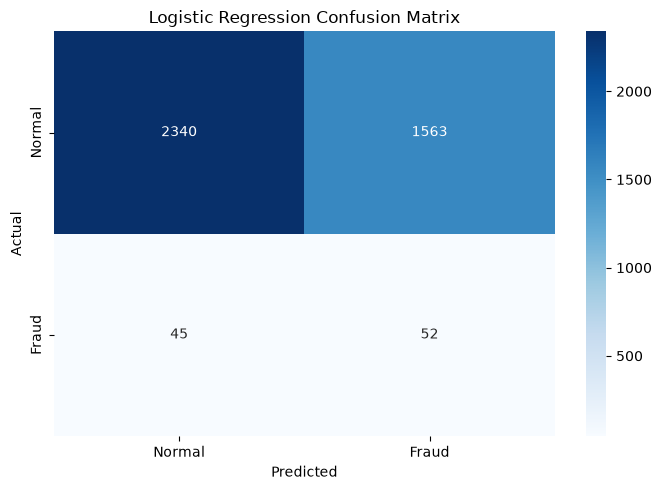

In [42]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Fraud"
    ],
    yticklabels=[
        "Normal",
        "Fraud"
    ]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

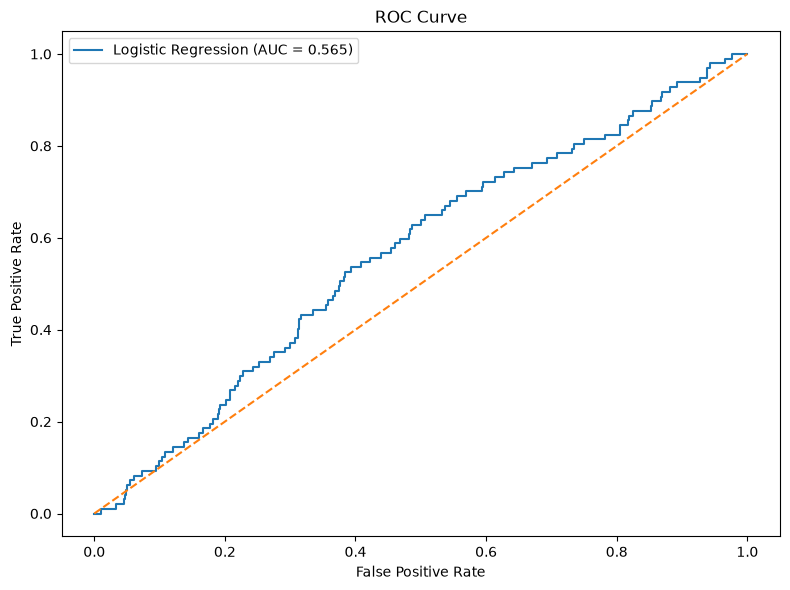

In [43]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.tight_layout()
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [45]:
rf_pred = random_forest_model.predict(X_test)

rf_proba = (
    random_forest_model
    .predict_proba(X_test)[:, 1]
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_proba
)

print("=" * 50)
print("RANDOM FOREST PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy : 0.9267
Precision: 0.0149
Recall   : 0.0309
F1 Score : 0.0201
ROC-AUC  : 0.5715


In [46]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "Normal",
            "Fraud"
        ]
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.95      0.96      3903
       Fraud       0.01      0.03      0.02        97

    accuracy                           0.93      4000
   macro avg       0.50      0.49      0.49      4000
weighted avg       0.95      0.93      0.94      4000



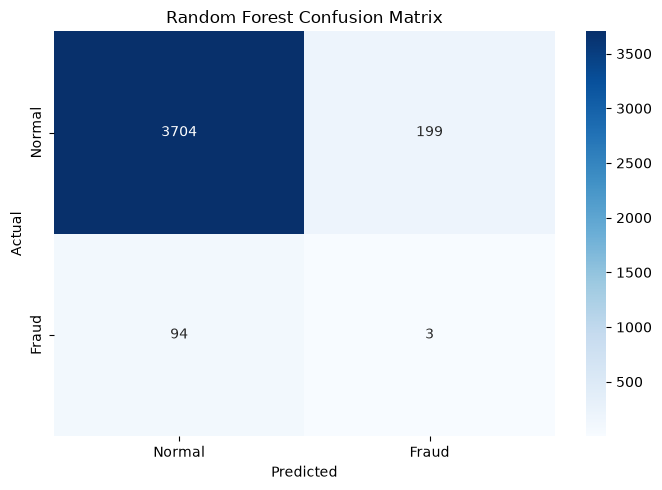

In [47]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Fraud"
    ],
    yticklabels=[
        "Normal",
        "Fraud"
    ]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

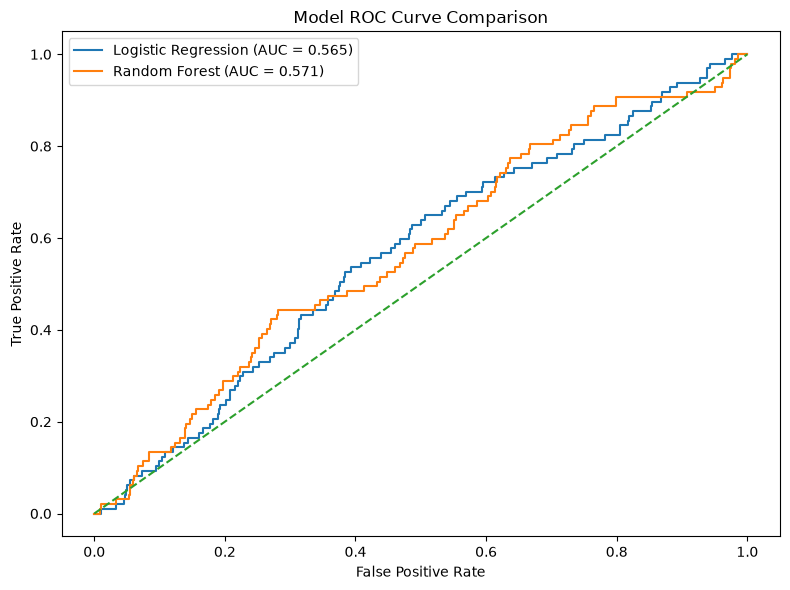

In [48]:
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Model ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()
plt.show()

In [49]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.59800,0.032198,0.536082,0.060748,0.565322
1,Random Forest,0.92675,0.014851,0.030928,0.020067,0.571472


In [50]:
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5980,0.0322,0.5361,0.0607,0.5653
1,Random Forest,0.9268,0.0149,0.0309,0.0201,0.5715


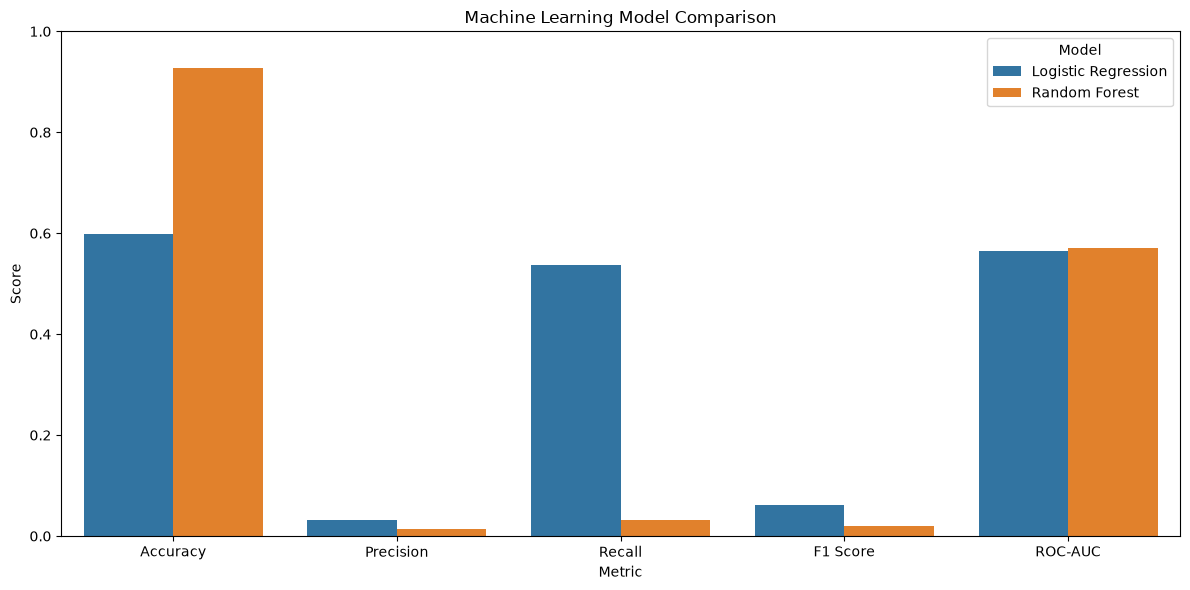

In [51]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_long = model_comparison.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [52]:
# Get the trained Random Forest classifier
rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

# Get the preprocessing step
rf_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

# Get feature names after preprocessing
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

# Get feature importance
importances = (
    rf_classifier.feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.head(20)

,Feature,Importance
0,numeric__amount,0.145711
1,numeric__day_of_month,0.116496
2,numeric__hour,0.108054
3,numeric__month,0.092349
4,numeric__day_of_week,0.062051
5,categorical__channel_Mobile,0.028160
6,categorical__channel_Online,0.025604
7,categorical__channel_Branch,0.018736
8,categorical__channel_ATM,0.018651
9,categorical__location_Hyderabad,0.018552


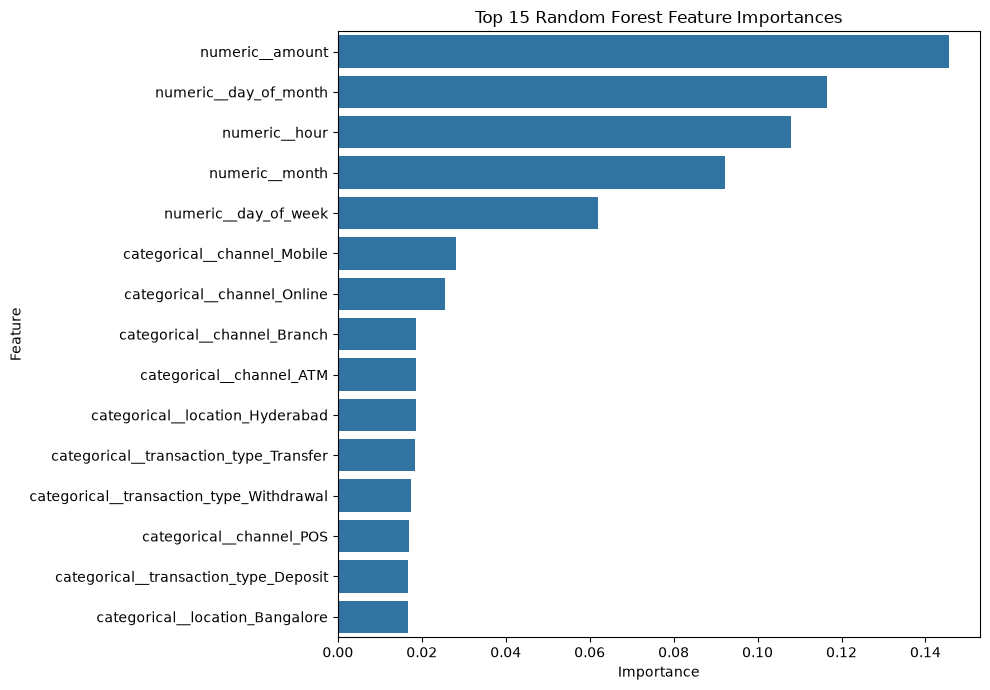

In [53]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()